# Project 1 — Decision Tree
## Loan Approval Prediction

Predicting whether a loan application should be approved based on income, credit score, debt-to-income ratio, employment years, and existing loans.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 800
income = np.random.normal(55000, 20000, n).clip(15000, 200000)
credit_score = np.random.normal(650, 90, n).clip(300, 850)
debt_ratio = np.random.uniform(0, 0.6, n)
employment_years = np.random.exponential(4, n).clip(0, 30)
existing_loans = np.random.poisson(1, n)

logit = (-4 + 0.00004*income + 0.01*credit_score - 6*debt_ratio + 0.15*employment_years - 0.4*existing_loans)
prob_approve = 1/(1+np.exp(-logit))
approved = np.random.binomial(1, prob_approve)

df = pd.DataFrame({'income': income, 'credit_score': credit_score, 'debt_ratio': debt_ratio,
                    'employment_years': employment_years, 'existing_loans': existing_loans, 'approved': approved})
df.head()


,income,credit_score,debt_ratio,employment_years,existing_loans,approved
0,64934.283060,734.445543,0.483842,12.019832,0,1
1,52234.713977,603.555974,0.275544,3.485483,0,1
2,67953.770762,658.650870,0.031174,2.295162,1,1
3,85460.597128,608.395224,0.471767,3.470848,1,1
4,50316.932506,610.895340,0.120818,2.908457,0,1


## 2. Preprocessing

In [3]:
X = df.drop('approved', axis=1)
y = df['approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# No scaling needed for trees


## 3. Train Model

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, criterion='gini', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.8625
Precision: 0.8545988258317025
Recall: 0.8625
F1: 0.8583908045977011

              precision    recall  f1-score   support

           0       0.29      0.25      0.27        16
           1       0.92      0.93      0.92       144

    accuracy                           0.86       160
   macro avg       0.60      0.59      0.60       160
weighted avg       0.85      0.86      0.86       160



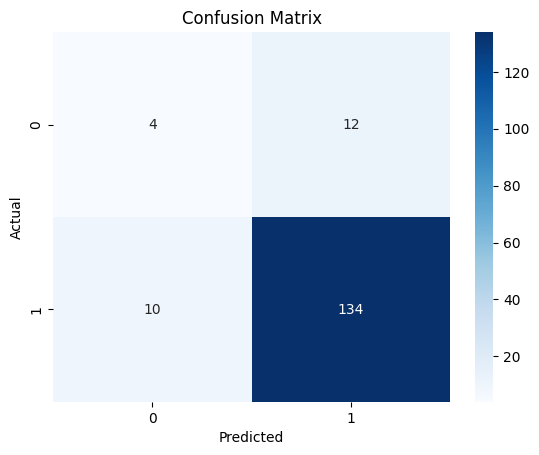

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Check `model.feature_importances_` to see which features drove decisions most (likely credit_score and debt_ratio).
- Try `sklearn.tree.plot_tree(model, feature_names=X.columns, filled=True)` to visualize the actual decision logic.
- Next steps: compare `max_depth=4` vs an unrestricted tree — watch train accuracy shoot to ~100% (overfitting) while test accuracy drops.

---
# Project 2 — Your Turn
**Dataset:** Breast Cancer Wisconsin (`sklearn.datasets.load_breast_cancer`) — predict malignant vs benign tumor from 30 numeric features.

```python
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
```
**Tasks:** train a Decision Tree, tune `max_depth` via cross-validation, visualize the tree, check feature importances, and evaluate with the full metric suite.
